In [1]:
import hoda
import tensorly as tl
tl.get_backend()

'cupy'

In [2]:
from moabb.paradigms import P300
from moabb.datasets import *
from mne.decoding import Scaler

tmin = 0
tmax=0.8
fmin=0.5
fmax = 16
sfreq = 32

paradigm = P300(resample=sfreq, tmin=tmin, tmax=tmax, fmin=fmin, fmax=fmax)
dataset = BNCI2014_009()
epochs, labels, meta = paradigm.get_data(dataset=dataset, 
                                         subjects=[3],
                                         return_epochs=True)

session = meta['session'][0]
idc = meta['session'] == session
epochs = epochs[idc]
labels = labels[idc]
meta = meta[idc]
#epochs._data = Scaler(scalings='mean').fit_transform(epochs._data)

<frozen importlib._bootstrap>:241: FutureWarning: mne.io.pick.pick_types is deprecated will be removed in 1.6, use documented public API instead. If no appropriate public API exists, please open an issue on GitHub.
<frozen importlib._bootstrap>:241: FutureWarning: mne.io.pick.pick_channels_regexp is deprecated will be removed in 1.6, use documented public API instead. If no appropriate public API exists, please open an issue on GitHub.
<frozen importlib._bootstrap>:241: FutureWarning: mne.io.pick.channel_type is deprecated will be removed in 1.6, use documented public API instead. If no appropriate public API exists, please open an issue on GitHub.
/usr/local/lib/python3.10/dist-packages/moabb/pipelines/__init__.py:26: ModuleNotFoundError: Tensorflow is not installed. You won't be able to use these MOABB pipelines if you attempt to do so.
  warn(


To use the get_shape_from_baseconcar, InputShapeSetterEEG, BraindecodeDatasetLoaderyou need to install `braindecode`.`pip install braindecode` or Please refer to `https://braindecode.org`.
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
1728 matching events found
No baseline correction applied


/usr/local/lib/python3.10/dist-packages/moabb/paradigms/base.py:354: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  X = mne.concatenate_epochs(X)


In [3]:
epochs

Number of events,576
Events,NonTarget: 480Target: 96
Time range,0.000 – 0.781 s
Baseline,off


Not setting metadata
576 matching events found
No baseline correction applied
0 projection items activated
combining channels using "gfp"


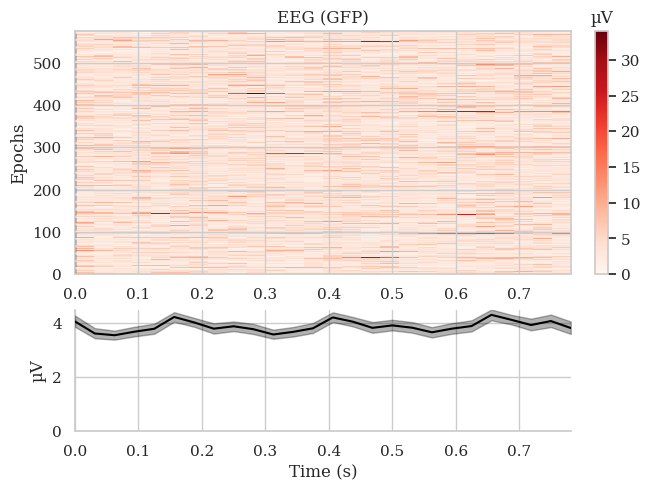

[<Figure size 640x480 with 3 Axes>]

In [4]:
epochs.plot_image()

In [5]:
meta

,subject,session,run
0,3,0,0
1,3,0,0
2,3,0,0
3,3,0,0
4,3,0,0
...,...,...,...
571,3,0,0
572,3,0,0
573,3,0,0
574,3,0,0


In [6]:
X = epochs.get_data()
y = labels

X.shape

/tmp/ipykernel_531/2444922706.py:1: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  X = epochs.get_data()


(576, 16, 26)

In [7]:
from hoda.hoda import HODA, f_multiway,trunc_eigh
from hoda.cov import ledoit_wolf_shrinkage, oas, mode_scatter
import warnings

from hoda.hoda import f_oneway, mode_scatter
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from hoda.classification import Vectorize
from sklearn.feature_selection import SelectFwe
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import pandas as pd
from sklearn.preprocessing import StandardScaler


hoda = HODA(
    rank=None,
    max_iter=512,
    tol=1e-12,
    init ='mlsvd',
    shrinkage='lw',
    toeplitz=(1,),
    obj='rt',
    solver='lobpcg',
    taper=False,
    extra_train_info=False,
    verbose=True,
)

hoda

HODA(init='mlsvd', max_iter=512, solver='lobpcg', toeplitz=(1,), tol=1e-12,
     verbose=True)

In [24]:
import matplotlib.pyplot as plt
from hoda.hoda import bic, aic, aicc,f_oneway
import math
import numpy as np

Fs = []
bics = []
aics=[]
aiccs=[]
lls = []
mses=[]
n_params = []
relevant_prop = []

n_samples = X.shape[0]
for r in range(1,min(X.shape[1:])+1):
    hoda.set_params(rank=r)
    hoda.fit(X,y)
    Xt = hoda.transform(X)
    mses.append(float(tl.metrics.regression.MSE(tl.tensor(X),hoda.inv_transform(Xt))))
    F = f_multiway(Xt,y,method='rt')
    Fs.append(float(F))
    log_like = tl.log(F)
    lls.append(float(log_like*n_samples))
    k = math.prod(hoda.ml_rank_)
    n_params.append(k)
    f,p = f_oneway(Xt,y)
    relevant_prop.append(float(tl.mean(tl.log(p))))
    bics.append(float(bic(n_samples,k,log_like)))
    aics.append(float(aic(n_samples,k,log_like)))
    aiccs.append(float(aicc(n_samples,k,log_like)))



ImportError: cannot import name 'bic' from 'hoda.hoda' (/project/src/hoda/hoda.py)

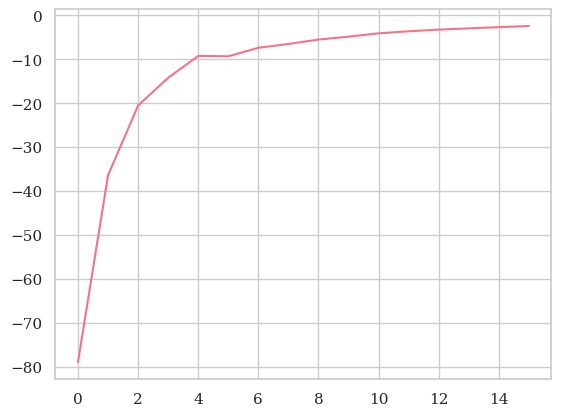

In [21]:
plt.plot(relevant_prop)

In [ ]:
plt.plot(mses)

In [ ]:
plt.plot(Fs)

In [ ]:
import numpy as np
plt.plot(lls)

In [ ]:
plt.plot(bics)
plt.plot(aics)
plt.plot(aiccs)